(sec:linear_regression)=

# Linear Regression

One of the simplest models in regression analysis is the linear model, where the estimator $\hat{f}(\beta; x_i)$ is given by a linear function of the form
:::{math}
:label: eq:linear_model
  \hat{f}(\beta; x_i) = \beta_0 + \beta_1 x_i
:::
with the scalar parameters $\beta_0$ and $\beta_1$. The regression analysis with the linear model is called linear regression.

## Theoretical Background

Let us now insert the linear model (*cf.* Eq. {eq}`eq:linear_model`) into the least squares loss function according to Eq. {eq}`eq:least_squares_loss`:
:::{math}
:label: eq:least_squares_loss_linear
  L(\beta; x, y) 
    = \sum_{i=1}^N\, (y_i - \beta_0 - \beta_1 x_i)^2 \,.
:::

Since our goal is to find the parameters $\beta$ that minimize the loss function (*cf.* Eq. {eq}`eq:least_squares_opt`), a necessary condition for a minimum is that the partial derivatives of $L$ with respect to $\beta_0$ and $\beta_1$ must vanish:
:::{math}
:enumerated: false
  \frac{\partial L}{\partial \beta_0} \stackrel{!}{=} 0 
  \quad \text{and} \quad
  \frac{\partial L}{\partial \beta_1} \stackrel{!}{=} 0 \,.
:::

After a somewhat tedious but simple calculation, we obtain the following system of equations: 
:::{math}
:label: eq:least_squares_linear_params

  \underbrace{
  \begin{pmatrix}
    \displaystyle N & \displaystyle \sum_{i=1}^N\, x_i \\[1.5em]
    \displaystyle \sum_{i=1}^N\, x_i & \displaystyle \sum_{i=1}^N\, x_i^2
  \end{pmatrix}}_{\displaystyle \bm{A}}
  \,
  \underbrace{
  \begin{pmatrix}
    \displaystyle \beta_0 \\[1.5em]
    \displaystyle \beta_1
  \end{pmatrix}
  \vphantom{
    \begin{pmatrix}
      \displaystyle \sum_{i=1}^N\, y_i \\[1.5em]
      \displaystyle \sum_{i=1}^N\, x_i y_i
    \end{pmatrix}
  }
  }_{\displaystyle \vec{\beta}}
  =
  \underbrace{
  \begin{pmatrix}
    \displaystyle \sum_{i=1}^N\, y_i \\[1.5em]
    \displaystyle \sum_{i=1}^N\, x_i y_i
  \end{pmatrix}}_ {\displaystyle \vec{b}} \,.
:::

```{tip} 📜 Derivation
:class: dropdown
:icon: false

First, we calculate the partial derivatives of $L$ with respect to $\beta_0$ and $\beta_1$. Since differentiation is linear, we can split the sum in Eq. {eq}`eq:least_squares_loss_linear` over the individual terms:
:::{math}
:enumerated: false
  \begin{aligned}
    \frac{\partial L}{\partial \beta_0} &= \frac{\partial}{\partial \beta_0} \sum_{i=1}^N\, (y_i - \beta_0 - \beta_1 x_i)^2 \\
    &= \sum_{i=1}^N\, \frac{\partial}{\partial \beta_0} (y_i - \beta_0 - \beta_1 x_i)^2 \\
    &= \sum_{i=1}^N\, -2 (y_i - \beta_0 - \beta_1 x_i) \,.
  \end{aligned}
:::

In the same manner, we proceed with the derivative with respect to $\beta_1$ and obtain
:::{math}
:enumerated: false
  \frac{\partial L}{\partial \beta_1} = \sum_{i=1}^N\, -2 x_i (y_i - \beta_0 - \beta_1 x_i) \,.
:::

Setting the derivatives equal to zero gives us the necessary conditions for a minimum:
:::{math}
:enumerated: false
  \begin{aligned}
    0 &= \sum_{i=1}^N\, -2 (y_i - \beta_0 - \beta_1 x_i) \\
    0 &= \sum_{i=1}^N\, -2 x_i (y_i - \beta_0 - \beta_1 x_i) \,.
  \end{aligned}
:::
The factor $(-2)$ does not matter, since the expression is set to zero. Therefore, we can omit it in the following.

By simply rearranging, we can write the above equations as a linear system of equations in $\beta_0$ and $\beta_1$:
:::{math}
:enumerated: false
  \begin{aligned}
    \sum_{i=1}^N\, \beta_0 + \sum_{i=1}^N\, \beta_1 x_i &= \sum_{i=1}^N\, y_i \\
    \sum_{i=1}^N\, \beta_0 x_i + \sum_{i=1}^N\, \beta_1 x_i^2 &= \sum_{i=1}^N\, x_i y_i \,.
  \end{aligned}
:::

Since the parameters $\beta_0$ and $\beta_1$ are independent of the data indices $i$, we can factor them out of the sums and obtain
:::{math}
:enumerated: false
  \begin{aligned}
    \beta_0 N + \beta_1 \sum_{i=1}^N\, x_i &= \sum_{i=1}^N\, y_i \\
    \beta_0 \sum_{i=1}^N\, x_i + \beta_1 \sum_{i=1}^N\, x_i^2 &= \sum_{i=1}^N\, x_i y_i \,,
  \end{aligned}
:::
where we used $\sum_{i=1}^N\, 1 = N$.
This system of equations is equivalent to the matrix equation in the linear-system equation above.

Solving this system of equations yields the optimal parameters $\beta_0$ and $\beta_1$ for the linear model.
```
The (at least formal) solution of the linear system above is $\vec{\beta} = \bm{A}^{-1} \vec{b}$, with the inverse of the matrix $\bm{A}$. A matrix is invertible if and only if its determinant is non-zero. The determinant of the system matrix $\bm{A}$ is
:::{math}
:enumerated: false

  \begin{aligned}
    \det(\bm{A}) &= N \sum_{i=1}^N\, x_i^2 - \left(\sum_{i=1}^N\, x_i\right)^2 \\
    &= N^2 \left[ 
      \frac{1}{N} \sum_{i=1}^N\, x_i^2 - \left(\frac{1}{N} \sum_{i=1}^N\, x_i\right)^2
    \right] \\
    &= N^2 \left[ 
      \frac{1}{N} \sum_{i=1}^N\, x_i^2 - \bar{x}^2
    \right] \\
    &= N^2 \left[ \frac{1}{N} \sum_{i=1}^N\, (x_i - \bar{x})^2 \right] \,,
  \end{aligned}
:::
where we have introduced the abbreviation $\bar{x} = \frac{1}{N} \sum_{i=1}^N\, x_i$ for the mean of the $x_i$.

If we had only one data point ($N=1$), or if all $x_i$ values were identical (making the variance zero), the determinant would be zero. This means that the matrix $\bm{A}$ is not invertible, and we do not obtain a unique solution for the linear model. A unique solution of the linear system above can only be found if there are at least two data points with different $x$ values.

Now let's implement linear regression using real-world data. We'll use NumPy's efficient built-in functions to solve the system of linear equations from the linear-system equation above.

## Implementation

Consider the following measurement data[^1] of the Lambert-Beer relationship for methylene blue in water at different concentrations $c$ and the corresponding absorbances $A$, measured at $610\ \mathrm{nm}$ with a layer thickness $d$ of 1 cm:

| $c$ / &micro;M | $A$      | $c$ / &micro;M | $A$      |
|:--------------:|:--------:|:--------------:|:--------:|
| 2.125          | 0.0572   | 23.38          | 0.8242   |
| 4.250          | 0.1391   | 25.50          | 0.9130   |
| 6.375          | 0.2049   | 27.63          | 1.0043   |
| 8.500          | 0.2754   | 29.75          | 1.0809   |
| 10.63          | 0.3420   | 31.88          | 1.1511   |
| 12.75          | 0.4139   | 34.00          | 1.2483   |
| 14.88          | 0.4956   | 36.13          | 1.3373   |
| 17.00          | 0.5815   | 38.25          | 1.4027   |
| 19.13          | 0.6806   | 40.38          | 1.4927   |
| 21.25          | 0.7481   | 42.50          | 1.5853   |

[^1]: The authors thank Dr. Hans-Christian Schmitt for providing the laboratory equipment used for these measurements.

Before we can proceed, we need to load the data into Python. The easiest way for such a small dataset is to enter it manually.

In [1]:
concentrations = [
    2.125, 4.250, 6.375, 8.500, 10.63, 12.75, 14.88, 17.00, 19.13, 21.25,
    23.38, 25.50, 27.63, 29.75, 31.88, 34.00, 36.13, 38.25, 40.38, 42.50,
]
absorbances = [
    0.0572, 0.1391, 0.2049, 0.2754, 0.3420, 
    0.4139, 0.4956, 0.5815, 0.6806, 0.7481,
    0.8242, 0.9130, 1.0043, 1.0809, 1.1511,
    1.2483, 1.3373, 1.4027, 1.4927, 1.5853,
]

Here we have defined the data in the variables `concentrations` and `absorbances` using Python *Lists*. This structure is indicated by the square brackets `[]` and the commas separating the values. The equal sign `=` assigns the list to the variable.

While Python lists offer basic functionality, the `numpy` package provides more powerful operations for numerical data. We'll import `numpy` using the common alias `np` (`import numpy as np`) to avoid repetitive typing. We then use `np.array()` to convert the Python lists into NumPy arrays:


In [2]:
import numpy as np

concentrations = np.array(concentrations)
absorbances = np.array(absorbances)

Note the assignment operator (`=`) in programming differs from mathematical equality. It assigns the result of the right-hand side evaluation to the variable on the left. This allows us to reuse the variable names (`concentrations`, `absorbances`) for the new NumPy arrays.

Next, we calculate the components needed for the matrix $\bm{A}$ and vector $\vec{b}$ (the linear-system equation above), primarily sums involving the `concentrations` ($x$) and `absorbances` ($y$) data. We use `np.sum()` for summation and check the number of data points, $N$, using `len()`.


In [3]:
# make sure the number of data points is the same
assert len(concentrations) == len(absorbances)

number_of_points = len(concentrations)
sum_x = np.sum(concentrations)
sum_x_sq = np.sum(concentrations**2)
sum_y = np.sum(absorbances)
sum_xy = np.sum(concentrations * absorbances)

We use the built-in function `len()` to get $N$. `np.sum()` calculates the sum of array elements. Note that `*` performs element-wise multiplication between arrays, and `**` performs element-wise exponentiation (e.g., `concentrations**2` squares each element).

:::{note} Note for Advanced Learners
:class: dropdown

The operators `*` and `**` can also be used as unary operators, *i.e.* operators with only 
one argument, contrary to binary operators which require two arguments, such as 
multiplication. As a unary operator, they have a different meaning. Interested readers 
with some programming experience can read the details, for example, [here](https://book.
pythontips.com/en/latest/args_and_kwargs.html).
:::

We can now assemble the system matrix $\bm{A}$ and the vector $\vec{b}$ from the linear-system equation above:

In [4]:
a_arr = np.array([
    [number_of_points, sum_x],
    [sum_x, sum_x_sq],
])
b_arr = np.array([sum_y, sum_xy])

Notice that a list of lists is used here to create the matrix (a *2D-array*). The inner lists correspond to the rows of the matrix. Now we can finally solve the linear system above to obtain the optimal parameters $\beta_0$ and $\beta_1$:

In [5]:
beta = np.linalg.solve(a_arr, b_arr)
print(beta)

[-0.04907034  0.03800109]


The function [`np.linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) solves a linear system of equations. We then output the solution with the `print` function.

To verify the implementation, if the expected values for $\beta_0$ and $\beta_1$ are known, one can compare them:

In [6]:
beta0 = beta[0]
beta1 = beta[1]
assert np.isclose(beta0, -0.04907034)
assert np.isclose(beta1, 0.03800109)

Here we first *indexed* the array `beta` using square brackets `[]`. Remember that indexing in Python starts at 0, so $\beta_0$ is `beta[0]` and $\beta_1$ is `beta[1]`. Then we compared these values with reference values.

:::{note}
It was not the exact values that were compared with `==`, since `float` numbers ([floating point numbers](https://en.wikipedia.org/wiki/Floating-point_arithmetic)) cannot be represented exactly in general. Therefore, the function [`np.isclose`](https://numpy.org/doc/stable/reference/generated/numpy.isclose.html) was used to compare the values with a (in this case preset) tolerance.
:::

The Lambert-Beer law states that the absorbance $A$ is linearly dependent on the concentration $c$ with the proportionality constant $\varepsilon d$, *i.e.*
:::{math}
:enumerated: false
  A = \varepsilon d c \,.
:::
The molar extinction coefficient $\varepsilon$ can be calculated from the slope parameter $\beta_1$ as
:::{math}
:enumerated: false
  \varepsilon = \beta_1 / d = 0.038\ \mathrm{{\mu M}^{-1}\cdot cm^{-1}} 
    = 38000\ \mathrm{M^{-1}\cdot cm^{-1}} \,.
:::

Now we have calculated the optimal parameters $\beta_0$ and $\beta_1$ for the dataset. How do we assess how well the linear regression fits the data?

There are various quantitative measures of fit quality, which we will explore later. For now, let's visualize the results graphically to assess the quality visually. This approach might be less rigorous than using mathematical metrics, but it provides valuable intuition.

## Visualisation

For visualizing the linear regression results, we will use the Python package `matplotlib`. We specifically import its `pyplot` submodule using the common alias `plt`:

In [7]:
import matplotlib.pyplot as plt

For graphical representation with `matplotlib`, we typically work with `Figure` and `Axes` objects. We can create them together using the function [`plt.subplots()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html):

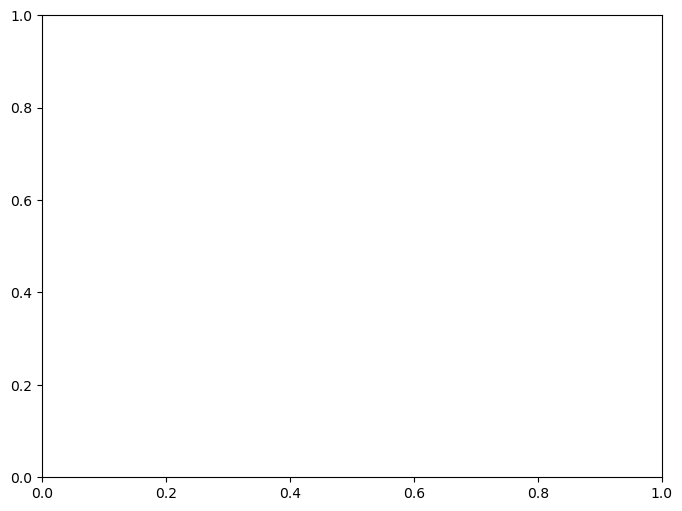

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

Here, the argument `figsize=(8, 6)` specifies the desired figure size in inches. This size is not fixed and can be freely adjusted.

Now we plot the measurement data as points and the linear regression as a line on the same axes. For this, we use the [`Axes.plot()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html) method:

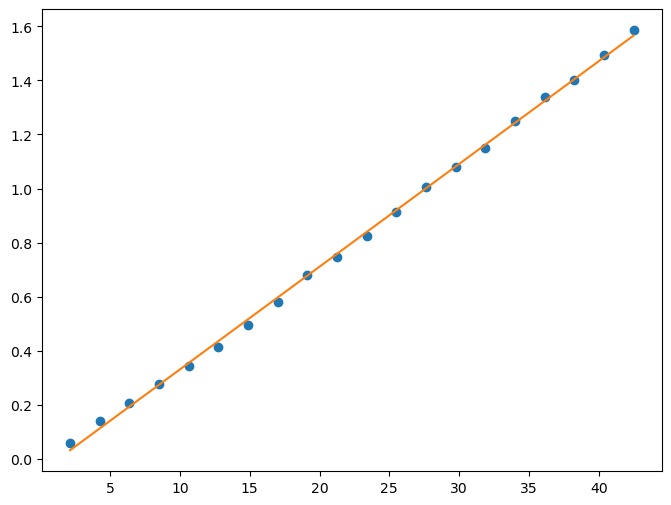

In [9]:
ax.plot(concentrations, absorbances, 'o', label='data')
ax.plot(concentrations, beta0 + beta1 * concentrations, label='fit')
display(fig)

We use the format string `'o'` to display the measurement data as points (other [markers](https://matplotlib.org/stable/api/markers_api.html) like `'s'` for squares or `'x'` for crosses are available). Without a marker specified, `plot` draws lines. The `label` argument in each `plot` call provides text for the legend.

:::{note} Note for Advanced Learners
:class: dropdown

The `plot` function is actually a method of the `Axes` class. This means that it is bound to instances of the `Axes` class. We will learn more about classes and methods in the following chapters. For now, it is sufficient to know that the `plot` function must be called on instances of the `Axes` class.
:::

To complete the diagram, we add axis labels and a legend:

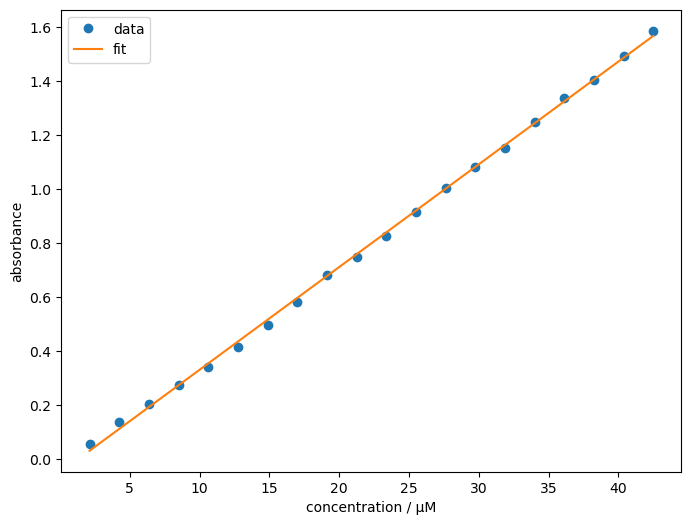

In [10]:
ax.set_xlabel('concentration / µM')
ax.set_ylabel('absorbance')

# automatically create a legend
ax.legend()

display(fig)

The functions `set_xlabel()` and `set_ylabel()` accept a string argument for the axis label. The `legend()` method adds a legend, automatically using the `label` arguments provided in the `plot` calls.

:::{note}
In a notebook, [`display()`](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.display) is a special helper function that explicitly renders an object as the output of the current cell. That is useful here because we construct the figure step by step across several cells and only want to show it once it is complete.

In a regular Python script, one would usually not use `display()`. Instead, after all plotting commands and formatting steps have been completed, the figure is typically shown with [`plt.show()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html), as illustrated in the next example.
:::

This diagram shows the results of the linear regression. While the aesthetic design is basic, we will learn more `matplotlib` features throughout this course to customize plots according to preference.

At first glance, the regression line seems to fit the measurement data very well. To examine the fit more closely, we can plot the residuals (the differences between observed data and the regression line) in a separate diagram.


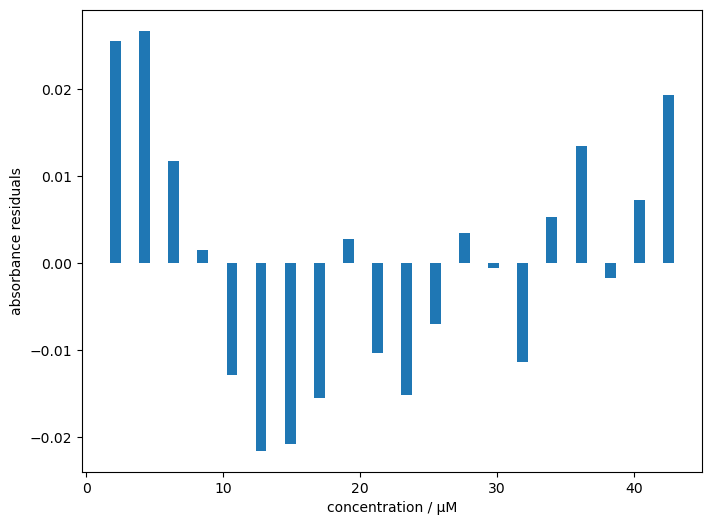

In [11]:
residuals = absorbances - (beta0 + beta1 * concentrations)

fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.bar(concentrations, residuals)
ax2.set_xlabel('concentration / µM')
ax2.set_ylabel('absorbance residuals')
plt.show()

After calculating the residuals and storing them in the `residuals` variable, we create a new figure and axes. We then plot the residuals as a bar chart using the `ax.bar()` method. The resulting diagram looks like this:

Now it is clearer that the deviations are positive at low and high concentrations, while negative at medium concentrations. This pattern could indicate a slight positive curvature in the data not captured by the linear model. Distinguishing between such systematic patterns and random noise often requires further analysis. Indeed, slight non-linearity exists in this data due to [deviations from the Lambert-Beer law](https://chem.libretexts.org/Bookshelves/Analytical_Chemistry/Instrumental_Analysis_(LibreTexts)/13%3A_Introduction_to_Ultraviolet_Visible_Absorption_Spectrometry/13.02%3A_Beer%27s_Law), especially at high concentrations. Those interested in the exact explanation for methylene blue in water can consult the cited publication [A. Fernández-Pérez, et al. *Dyes and Pigments* **2019**](https://www.sciencedirect.com/science/article/pii/S014372081831845X). Whether the linear regression is *adequate* in this case depends on the required accuracy of the model.

:::{hint} Tip for Programming Style

Here we placed the `import` statements in the respective sections to emphasise the dependencies of the different parts of the script. The resulting code can be interpreted without errors. However, it is common in Python to place the imports at the beginning of the script, *i.e.*
```python
import numpy as np
import matplotlib.pyplot as plt

# Rest of your code
```
:::

---

## Exercises and References

### Self-Study Questions

- How does the mathematical form of the $\ell_1$-norm loss differ from the $\ell_2$-norm loss? Briefly explain why this difference makes $\ell_1$ (Least Absolute Deviations) less sensitive to outliers than $\ell_2$ (Least Squares).

- In the context of minimizing the least squares loss function for linear regression, why do we set the partial derivatives of the loss function with respect to $\beta_0$ and $\beta_1$ to zero? What does this step represent in the optimization process?

- The text mentions that the matrix $\bm{A}$ is invertible if its determinant is non-zero. For the linear regression case, when is the determinant of $\bm{A}$ zero? What does this imply about the data $x$?

- Given a Python list of numbers, say `data = [1, 2, 3, 4, 5]`, write a short Python code snippet (without using NumPy) to calculate the sum of the squares of these numbers.

### Challenge Questions

- Derive the formula for the optimal slope $\beta_1$ in a linear model *without* an intercept ($\hat{y}_i = \beta_1 x_i$) using the least squares principle. How does the resulting formula for $\beta_1$ compare to the one derived for the model *with* an intercept?

- Investigate and implement measures of fit quality for linear regression, such as the coefficient of determination $R^2$, the mean absolute error (MAE), and the root mean squared error (RMSE). How do these metrics relate to the residuals?

- Linear regression is often used with the least squares loss function because it arises naturally in Maximum Likelihood Estimation (MLE) under the assumption that the residuals are normally distributed with equal variance. MLE finds model parameters that make the observed data $y$ *most probable* given the inputs $x$ by maximizing the likelihood function. For the methylene blue data, is it reasonable to assume normally distributed residuals? Explain your reasoning.

### Further Reading

- James *et al.*, *An Introduction to Statistical Learning*, Chapter 3
- Bishop, *Pattern Recognition and Machine Learning*, Section 3.1
- Murphy, *Machine Learning: A Probabilistic Perspective*, Chapter 7
